# Agent Outcome HPO

This notebook loads a NeuralSignal feature run, extracts an agent end-state label from a JSON column, maps those string outcomes to a binary target, saves the prepared dataset, then runs a small Optuna search over an XGBoost classifier.

In [46]:
# Parameters: edit this cell first.
from pathlib import Path

# Input run. Can point at a run directory under runs/ or directly at a parquet file.
RESULTS_PATH = Path("runs/remote/malt-full-normal-bs1")

# Activation feature selection. These must match feature column names in the parquet file.
SELECTED_FEATURES = [
    # "feature_set__feature_name",
]

# Columns and output names.
JSON_COLUMN = "metadata_json"
AGENT_OUTCOME_COLUMN = "agent_outcome"
TARGET_COLUMN = "target"
OUTPUT_DIR = Path("runs/notebook-agent-outcome-hpo")
PREPARED_DATASET_FILENAME = "agent_outcome_prepared.parquet"
PREDICTIONS_FILENAME = "agent_outcome_predictions.csv"
METRICS_FILENAME = "agent_outcome_metrics.json"

# Where to look inside JSON_COLUMN. Dotted paths are supported.
OUTCOME_KEY_CANDIDATES = [
    "agent_outcome",
    "agent_end_state",
    "end_state",
    "final_state",
    "outcome",
    "status",
    "result",
    "run_labels",
    "labels",
    "metadata.agent_outcome",
    "metadata.agent_end_state",
    "metadata.end_state",
    "metadata.run_labels",
]
SEARCH_JSON_RECURSIVELY = True
NORMALIZE_OUTCOME_TEXT = True

# Binary target mapping, modeled after the train CLI behavior.
# Positive outcomes become 1. Explicit negative outcomes become 0.
# UNMATCHED_OUTCOME can be "negative", "exclude", or "error".
POSITIVE_OUTCOMES = ["gives_up", "gave_up"]
NEGATIVE_OUTCOMES = ["normal"]
UNMATCHED_OUTCOME = "negative"

# Model/evaluation settings.
RANDOM_STATE = 42
TEST_SIZE = 0.25
N_OPTUNA_TRIALS = 8
PREDICTION_THRESHOLD = 0.5
OPTUNA_DIRECTION = "maximize"
OPTUNA_METRIC = "auc"

# XGBoost fixed settings. The HPO cell tunes a small set on top of these.
XGB_BASE_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "device": "cpu",
    "n_jobs": 4,
    "random_state": RANDOM_STATE,
}

# Display and plotting.
TOP_FEATURE_IMPORTANCE_COUNT = 25
FIGSIZE = (6, 5)
SAVE_FIGURES = True
AUC_FIGURE_FILENAME = "roc_curve.png"
CONFUSION_MATRIX_FIGURE_FILENAME = "confusion_matrix.png"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Setup

In [47]:
import json
import math
from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

try:
    import optuna
except ImportError as exc:
    raise ImportError("Install optuna before running HPO: uv pip install optuna") from exc

plt.style.use("default")

## Helpers

In [48]:
def read_feature_run(path: Path) -> pd.DataFrame:
    path = Path(path)
    if path.is_file():
        return pd.read_parquet(path)

    manifest_path = path / "manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if manifest.get("state", "completed") != "completed":
            raise ValueError(f"Feature run is not completed: {path}")
        parquet_paths = [path / shard["path"] for shard in manifest.get("shards", [])]
    else:
        parquet_paths = sorted((path / "features").rglob("*.parquet"))
        if not parquet_paths:
            parquet_paths = sorted(path.glob("*.parquet"))

    if not parquet_paths:
        raise FileNotFoundError(f"No parquet files found under {path}")
    return pd.concat([pd.read_parquet(item) for item in parquet_paths], ignore_index=True)


def parse_json_value(value):
    if isinstance(value, Mapping):
        return dict(value)
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        return json.loads(value) if value.strip() else {}
    if pd.isna(value):
        return {}
    return value


def get_dotted_value(row, dotted_key):
    current = row
    for part in dotted_key.split("."):
        if not isinstance(current, Mapping) or part not in current:
            return None
        current = current[part]
    return current


def recursive_find(row, key_names):
    if isinstance(row, Mapping):
        for key, value in row.items():
            if key in key_names:
                return value
            found = recursive_find(value, key_names)
            if found is not None:
                return found
    elif isinstance(row, list):
        for value in row:
            found = recursive_find(value, key_names)
            if found is not None:
                return found
    return None


def normalize_outcome(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    if isinstance(value, Mapping):
        return json.dumps(value, sort_keys=True)
    if isinstance(value, list):
        if len(value) == 1:
            return normalize_outcome(value[0])
        return ",".join(str(item) for item in value)
    text = str(value).strip()
    return text.lower() if NORMALIZE_OUTCOME_TEXT else text


def extract_agent_outcome(json_value):
    row = parse_json_value(json_value)
    for key in OUTCOME_KEY_CANDIDATES:
        value = get_dotted_value(row, key)
        if value is not None:
            return normalize_outcome(value)
    if SEARCH_JSON_RECURSIVELY:
        key_names = {key.split(".")[-1] for key in OUTCOME_KEY_CANDIDATES}
        return normalize_outcome(recursive_find(row, key_names))
    return None


def encode_binary_target(outcomes: pd.Series) -> pd.Series:
    if UNMATCHED_OUTCOME not in {"negative", "exclude", "error"}:
        raise ValueError('UNMATCHED_OUTCOME must be "negative", "exclude", or "error"')

    positive = {normalize_outcome(item) for item in POSITIVE_OUTCOMES}
    negative = {normalize_outcome(item) for item in NEGATIVE_OUTCOMES}
    overlap = positive & negative
    if overlap:
        raise ValueError(f"Positive and negative outcomes overlap: {sorted(overlap)}")

    encoded = []
    for value in outcomes:
        if pd.isna(value):
            encoded.append(np.nan)
        elif value in positive:
            encoded.append(1)
        elif value in negative or UNMATCHED_OUTCOME == "negative":
            encoded.append(0)
        elif UNMATCHED_OUTCOME == "exclude":
            encoded.append(np.nan)
        else:
            raise ValueError(f"Unmapped outcome: {value!r}")
    return pd.Series(encoded, index=outcomes.index, dtype="float")


def classification_metrics(y_true, scores, threshold=PREDICTION_THRESHOLD):
    preds = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    ratio = lambda numerator, denominator: float(numerator / denominator) if denominator else float("nan")
    return {
        "auc": float(roc_auc_score(y_true, scores)) if len(set(y_true)) == 2 else float("nan"),
        "auprc": float(average_precision_score(y_true, scores)) if tp + fn else float("nan"),
        "accuracy": float(accuracy_score(y_true, preds)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, preds, zero_division=0)),
        "specificity": ratio(tn, tn + fp),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, preds)),
        "log_loss": float(log_loss(y_true, scores, labels=[0, 1])),
        "brier_score": float(brier_score_loss(y_true, scores)),
        "false_positive_rate": ratio(fp, tn + fp),
        "false_negative_rate": ratio(fn, tp + fn),
        "negative_predictive_value": ratio(tn, tn + fn),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def clean_json(value):
    if isinstance(value, float) and not math.isfinite(value):
        return None
    if isinstance(value, dict):
        return {key: clean_json(item) for key, item in value.items()}
    if isinstance(value, list):
        return [clean_json(item) for item in value]
    return value

In [49]:
# OVERRIDE_READ_FEATURE_RUN_RECURSIVE_FEATURES
# Run this cell if your open notebook still shows the older loader.
def resolve_results_path(path: Path) -> Path:
    path = Path(path).expanduser()
    if path.exists():
        return path
    if path.is_absolute():
        raise FileNotFoundError(f"RESULTS_PATH does not exist: {path}")

    candidates = [Path.cwd() / path, *[parent / path for parent in Path.cwd().parents]]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    tried = "\n".join(str(candidate) for candidate in candidates[:8])
    raise FileNotFoundError(f"RESULTS_PATH does not exist from this notebook session: {path}\nTried:\n{tried}")


def read_feature_run(path: Path) -> pd.DataFrame:
    path = resolve_results_path(path)
    print(f"Resolved RESULTS_PATH to: {path}")
    if path.is_file():
        return pd.read_parquet(path)

    manifest_path = path / "manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        if manifest.get("state", "completed") != "completed":
            raise ValueError(f"Feature run is not completed: {path}")
        parquet_paths = [path / shard["path"] for shard in manifest.get("shards", [])]
        parquet_paths = [item for item in parquet_paths if item.exists()]
    else:
        parquet_paths = []

    if not parquet_paths:
        parquet_paths = sorted((path / "features").rglob("*.parquet"))
    if not parquet_paths:
        parquet_paths = sorted(path.rglob("*.parquet"))

    if not parquet_paths:
        raise FileNotFoundError(f"No parquet files found under {path / 'features'} or {path}")
    print(f"Found {len(parquet_paths):,} parquet file(s). First: {parquet_paths[0]}")
    return pd.concat([pd.read_parquet(item) for item in parquet_paths], ignore_index=True)


## Load And Prepare Data

In [ ]:
raw = read_feature_run(RESULTS_PATH)
print(f"Loaded {len(raw):,} rows and {len(raw.columns):,} columns from {RESULTS_PATH}")

if JSON_COLUMN not in raw.columns:
    raise KeyError(f"JSON_COLUMN={JSON_COLUMN!r} is not present. Available columns include: {list(raw.columns[:20])}")
activation_features = [column for column in raw.columns if "__" in column]
if not SELECTED_FEATURES:
    SELECTED_FEATURES = activation_features
    print("SELECTED_FEATURES is empty; using all activation features.")

missing_features = [feature for feature in SELECTED_FEATURES if feature not in raw.columns]
if missing_features:
    raise KeyError(f"Selected features not found: {missing_features[:20]}")
if not SELECTED_FEATURES:
    raise ValueError("No activation feature columns found. Expected feature columns containing '__'.")

extra_activation_features = sorted(set(activation_features) - set(SELECTED_FEATURES))
print(f"Activation feature columns found: {len(activation_features):,}")
print(f"Selected activation features kept: {len(SELECTED_FEATURES):,}")
print(f"Activation features filtered out: {len(extra_activation_features):,}")

prepared = raw[[JSON_COLUMN, *SELECTED_FEATURES]].copy()
prepared[AGENT_OUTCOME_COLUMN] = raw[JSON_COLUMN].apply(extract_agent_outcome)

print("\nAgent outcome distribution before binary mapping:")
display(prepared[AGENT_OUTCOME_COLUMN].value_counts(dropna=False).rename_axis(AGENT_OUTCOME_COLUMN).to_frame("rows"))

Resolved RESULTS_PATH to: E:\Programming\neuralsignal\neuralsignal\runs\remote\malt-full-normal-bs1
Found 8 parquet file(s). First: E:\Programming\neuralsignal\neuralsignal\runs\remote\malt-full-normal-bs1\features\part-00000.parquet


In [40]:
prepared[TARGET_COLUMN] = encode_binary_target(prepared[AGENT_OUTCOME_COLUMN])
excluded_rows = int(prepared[TARGET_COLUMN].isna().sum())
audit_prepared = prepared[prepared[TARGET_COLUMN].notna()].reset_index(drop=True)
audit_prepared[TARGET_COLUMN] = audit_prepared[TARGET_COLUMN].astype(int)

print(f"Excluded rows: {excluded_rows:,}")
print("\nBinary target distribution:")
display(audit_prepared[TARGET_COLUMN].value_counts(dropna=False).sort_index().rename_axis(TARGET_COLUMN).to_frame("rows"))

if audit_prepared[TARGET_COLUMN].nunique() != 2:
    raise ValueError("Binary target must contain both 0 and 1 after mapping.")
if min(audit_prepared[TARGET_COLUMN].value_counts()) < 2:
    raise ValueError("Each class needs at least two rows for stratified train/test splitting.")

prepared = audit_prepared[[*SELECTED_FEATURES, TARGET_COLUMN]].copy()
prepared_path = OUTPUT_DIR / PREPARED_DATASET_FILENAME
prepared.to_parquet(prepared_path, index=False)
print(f"Saved feature-only prepared dataset to {prepared_path.resolve()}")
print(f"Prepared shape: {prepared.shape[0]:,} rows x {prepared.shape[1]:,} columns")


Excluded rows: 0

Binary target distribution:


,rows
target,
0,487
1,13


Saved feature-only prepared dataset to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_prepared.parquet
Prepared shape: 500 rows x 7,129 columns


## Train/Test Split

In [41]:
x = prepared[SELECTED_FEATURES].astype(float)
y = prepared[TARGET_COLUMN].astype(int)

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train rows: {len(x_train):,}; test rows: {len(x_test):,}; features: {len(SELECTED_FEATURES):,}")
display(pd.DataFrame({"train": y_train.value_counts().sort_index(), "test": y_test.value_counts().sort_index()}))

Train rows: 375; test rows: 125; features: 7,128


,train,test
target,,
0,365,122
1,10,3


## Small Optuna HPO

In [42]:
def objective(trial):
    params = {
        **XGB_BASE_PARAMS,
        "n_estimators": trial.suggest_int("n_estimators", 75, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }
    model = XGBClassifier(**params)
    model.fit(x_train, y_train)
    scores = model.predict_proba(x_test)[:, 1]
    metrics = classification_metrics(y_test, scores)
    return metrics[OPTUNA_METRIC]


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction=OPTUNA_DIRECTION, sampler=sampler)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

print(f"Best {OPTUNA_METRIC}: {study.best_value:.4f}")
print("Best parameters:")
display(pd.Series(study.best_params).to_frame("value"))

trials = study.trials_dataframe(attrs=("number", "value", "params", "state"))
display(trials.sort_values("value", ascending=(OPTUNA_DIRECTION == "minimize")).head(10))

[I 2026-09-13 22:32:37,539] A new study created in memory with name: no-name-af95781e-501b-43e9-b791-679f4b3c99a6
[I 2026-09-13 22:32:43,919] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 159, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2.403950683025824, 'reg_lambda': 0.13066739238053282}. Best is trial 0 with value: 1.0.
[I 2026-09-13 22:32:52,592] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 270, 'max_depth': 6, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 8.491983767203795, 'reg_lambda': 0.26587543983272705}. Best is trial 0 with value: 1.0.
[I 2026-09-13 22:32:57,610] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 116, 'max_depth': 3, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.77277800745

Best auc: 1.0000
Best parameters:


,value
n_estimators,159.000000
max_depth,8.000000
learning_rate,0.120571
subsample,0.839463
colsample_bytree,0.662407
min_child_weight,2.403951
reg_lambda,0.130667


,number,value,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_lambda,params_subsample,state
0,0,1.0,0.662407,0.120571,8,2.403951,159,0.130667,0.839463,COMPLETE
2,2,1.0,0.772778,0.028145,3,3.621062,116,1.673809,0.809903,COMPLETE
3,3,1.0,0.914070,0.034766,4,2.797064,106,1.067748,0.782428,COMPLETE
5,5,1.0,0.776061,0.013940,4,2.098344,257,0.978034,0.873693,COMPLETE
1,1,0.5,0.987964,0.111150,6,8.491984,270,0.265875,0.608234,COMPLETE
4,4,0.5,0.626021,0.078962,2,9.539970,208,8.536190,0.668210,COMPLETE
6,6,0.5,0.724684,0.024113,8,5.680612,82,1.239997,0.865009,COMPLETE
7,7,0.5,0.957931,0.139626,8,6.381100,116,6.978281,0.975800,COMPLETE


## Best Model Metrics

In [43]:
best_model = XGBClassifier(**XGB_BASE_PARAMS, **study.best_params)
best_model.fit(x_train, y_train)
test_scores = best_model.predict_proba(x_test)[:, 1]
test_preds = (test_scores >= PREDICTION_THRESHOLD).astype(int)
metrics = classification_metrics(y_test, test_scores)
metrics.update({
    "train_rows": len(x_train),
    "test_rows": len(x_test),
    "feature_count": len(SELECTED_FEATURES),
    "threshold": PREDICTION_THRESHOLD,
})

print("Held-out metrics:")
display(pd.Series(metrics).to_frame("value"))

print("\nClassification report:")
display(pd.DataFrame(classification_report(y_test, test_preds, labels=[0, 1], output_dict=True, zero_division=0)).T)

predictions = pd.DataFrame({
    "row_index": x_test.index,
    "agent_outcome": audit_prepared.loc[x_test.index, AGENT_OUTCOME_COLUMN].to_numpy(),
    "label": y_test.to_numpy(),
    "score": test_scores,
    "prediction": test_preds,
})
predictions_path = OUTPUT_DIR / PREDICTIONS_FILENAME
predictions.to_csv(predictions_path, index=False)

metrics_path = OUTPUT_DIR / METRICS_FILENAME
metrics_payload = {
    "metrics": metrics,
    "best_params": study.best_params,
    "selected_features": SELECTED_FEATURES,
    "positive_outcomes": POSITIVE_OUTCOMES,
    "negative_outcomes": NEGATIVE_OUTCOMES,
    "unmatched_outcome": UNMATCHED_OUTCOME,
}
metrics_path.write_text(json.dumps(clean_json(metrics_payload), indent=2), encoding="utf-8")
print(f"Saved predictions to {predictions_path.resolve()}")
print(f"Saved metrics to {metrics_path.resolve()}")

Held-out metrics:


,value
auc,1.000000
auprc,1.000000
accuracy,1.000000
precision,1.000000
recall_sensitivity,1.000000
specificity,1.000000
f1,1.000000
mcc,1.000000
log_loss,0.022217
brier_score,0.004381



Classification report:


,precision,recall,f1-score,support
0,1.0,1.0,1.0,122.0
1,1.0,1.0,1.0,3.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,125.0
weighted avg,1.0,1.0,1.0,125.0


Saved predictions to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_predictions.csv
Saved metrics to E:\Programming\neuralsignal\neuralsignal\notebooks\runs\notebook-agent-outcome-hpo\agent_outcome_metrics.json


## Charts

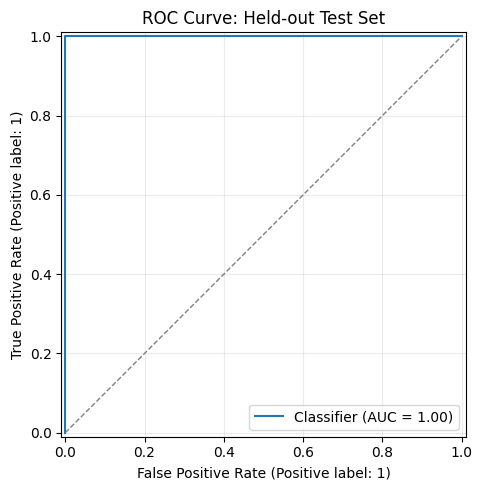

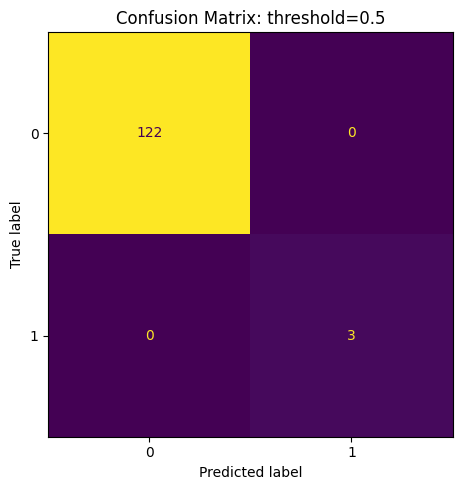

In [44]:
fig, ax = plt.subplots(figsize=FIGSIZE)
RocCurveDisplay.from_predictions(y_test, test_scores, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("ROC Curve: Held-out Test Set")
ax.grid(alpha=0.25)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / AUC_FIGURE_FILENAME, dpi=150)
plt.show()

matrix = confusion_matrix(y_test, test_preds, labels=[0, 1])
fig, ax = plt.subplots(figsize=FIGSIZE)
display_cm = ConfusionMatrixDisplay(matrix, display_labels=["negative", "positive"])
display_cm.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title(f"Confusion Matrix: threshold={PREDICTION_THRESHOLD}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

threshold = matrix.max() / 2 if matrix.size and matrix.max() else 0
for text in display_cm.text_.ravel():
    value = int(text.get_text())
    text.set_color("white" if value > threshold else "#111827")
    text.set_fontweight("bold")
    text.set_fontsize(12)

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / CONFUSION_MATRIX_FIGURE_FILENAME, dpi=150)
plt.show()


## Feature Importance

,feature,importance
4390,layer_distribution__bin_2_outputs_decoder.T5Bl...,0.112189
5375,layer_distribution__bin_7_outputs_decoder.T5Bl...,0.103204
3585,layer_distribution__bin_7_outputs_encoder.T5Bl...,0.091622
28,zones__512_encoder.T5Block.T5LayerSelfAttentio...,0.090861
210,zones__512_encoder.T5Block.T5LayerFF.DenseRelu...,0.083310
3252,layer_distribution__bin_4_outputs_encoder.T5Bl...,0.074185
435,zones__512_encoder.T5Block.T5LayerSelfAttentio...,0.072646
414,zones__512_encoder.T5Block.T5LayerSelfAttentio...,0.057257
5370,layer_distribution__bin_2_outputs_decoder.T5Bl...,0.053153
248,zones__512_encoder.T5Block.T5LayerSelfAttentio...,0.049257


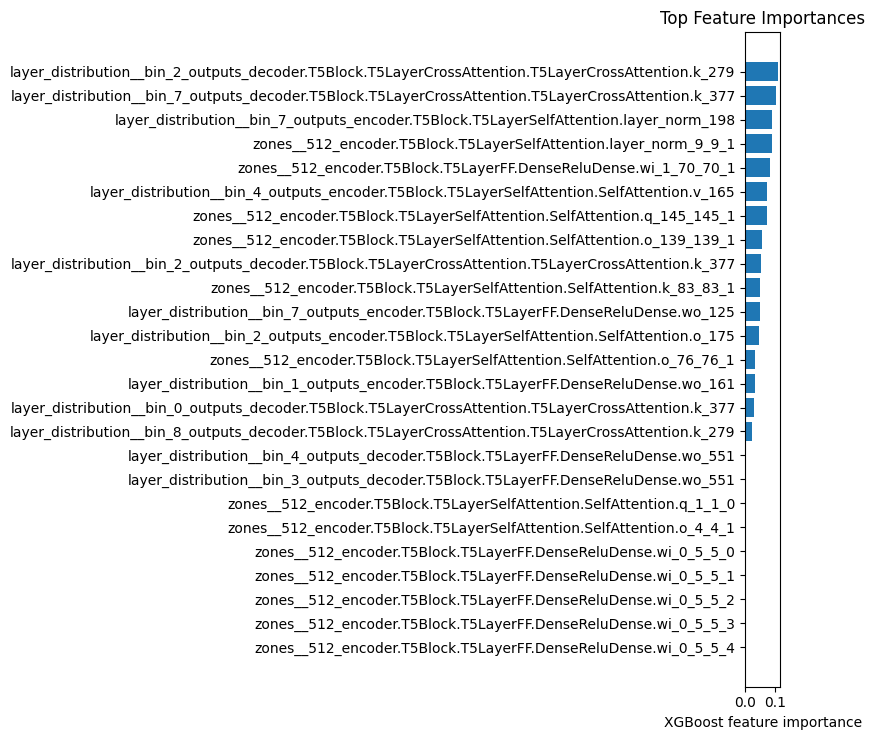

In [45]:
importance = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance["importance"] = importance["importance"].astype(float)
top_10_feature_importances = importance.head(10).to_dict(orient="records")

print("Top 10 feature importances JSON:")
print(json.dumps(top_10_feature_importances, indent=2))
(OUTPUT_DIR / "top_10_feature_importances.json").write_text(
    json.dumps(top_10_feature_importances, indent=2),
    encoding="utf-8",
)

display(importance.head(TOP_FEATURE_IMPORTANCE_COUNT))

plot_rows = importance.head(TOP_FEATURE_IMPORTANCE_COUNT).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(4, len(plot_rows) * 0.3)))
ax.barh(plot_rows["feature"], plot_rows["importance"], color="#2563eb")
ax.set_title("Top Feature Importances")
ax.set_xlabel("XGBoost feature importance")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()
